# Simple Networks --- MMSB §2.1.3

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lab-biotek-bio-ugm/TKBM262615_Practicals/blob/main/notebooks/02_simple_networks.ipynb)

This notebook is a hands-on companion for **TBM263214 Komputasi Biologi** (Computational Biology), Biomedical Engineering, Universitas Gadjah Mada. It simulates the four canonical "simple network" examples from **Ingalls, B. P. (2013), *Mathematical Modeling in Systems Biology: An Introduction*, MIT Press, Chapter 2, §2.1.3**:

1. **Decay**
2. **Production and Decay**
3. **Irreversible Conversion**
4. **Reversible Conversion**

The official textbook PDF (with solutions) is available at: <https://www.math.uwaterloo.ca/~bingalls/MMSB/MMSB_w_solutions.pdf>

**How to use this notebook:** each example has a code cell with a short **parameters** block at the top. Edit the values and re-run the cell to explore how the system behaves --- no extra setup (e.g. sliders/widgets) required, so it runs the same way in Jupyter and in Google Colab.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


## Example I: Decay

The simplest possible network: a single species $A$ that decays (degrades) with first-order kinetics.

$$
\frac{dA}{dt} = -k_d A
$$

This has the closed-form analytical solution

$$
A(t) = A_0 e^{-k_d t},
$$

and, independent of $A_0$, the concentration falls to half its value after the **half-life**

$$
t_{1/2} = \frac{\ln 2}{k_d}.
$$


Half-life: theory = 1.386, numeric (interpolated) = 1.386


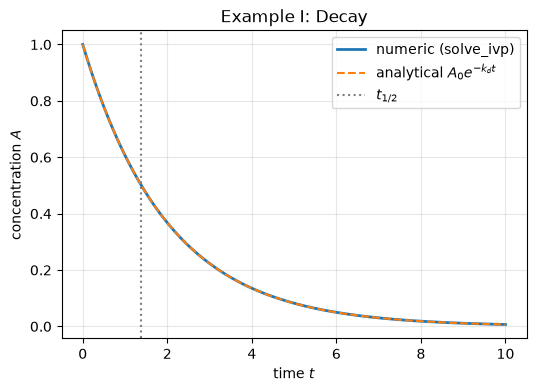

In [2]:
# --- Parameters (edit and re-run) ---
kd = 0.5      # decay rate constant (1/time)
A0 = 1.0      # initial concentration of A
t_span = (0, 10)
t_eval = np.linspace(*t_span, 300)

def decay_rhs(t, y, kd):
    A = y[0]
    return [-kd * A]

sol = solve_ivp(decay_rhs, t_span, [A0], t_eval=t_eval, args=(kd,))
A_numeric = sol.y[0]
A_analytical = A0 * np.exp(-kd * t_eval)

# --- Sanity check: half-life ---
t_half_theory = np.log(2) / kd
t_half_numeric = np.interp(A0 / 2, A_numeric[::-1], t_eval[::-1])
print(f"Half-life: theory = {t_half_theory:.3f}, numeric (interpolated) = {t_half_numeric:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_eval, A_numeric, label="numeric (solve_ivp)", lw=2)
ax.plot(t_eval, A_analytical, "--", label=r"analytical $A_0 e^{-k_d t}$")
ax.axvline(t_half_theory, color="gray", ls=":", label=r"$t_{1/2}$")
ax.set_xlabel("time $t$")
ax.set_ylabel("concentration $A$")
ax.set_title("Example I: Decay")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


The numeric and analytical curves overlap almost exactly, confirming `solve_ivp` recovers the known solution. Notice the half-life does not depend on $A_0$ --- halving time is a property of the *rate constant* alone, the same reasoning behind drug clearance or radioactive decay half-lives.


## Example II: Production and Decay

Now add a constant zeroth-order production term $k_p$ alongside first-order decay:

$$
\frac{dA}{dt} = k_p - k_d A
$$

This also has a closed-form solution:

$$
A(t) = \frac{k_p}{k_d} + \left(A_0 - \frac{k_p}{k_d}\right) e^{-k_d t}.
$$

As $t \to \infty$, the concentration approaches a **steady state**

$$
A_{ss} = \frac{k_p}{k_d}.
$$


Steady state: theory = 4.000, numeric (final value) = 3.973


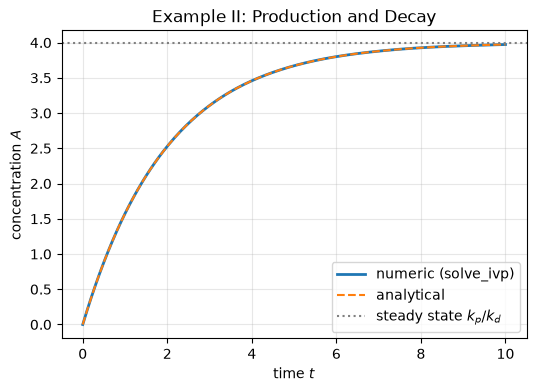

In [3]:
# --- Parameters (edit and re-run) ---
kp = 2.0      # production rate (amount/time)
kd = 0.5      # decay rate constant (1/time)
A0 = 0.0      # initial concentration of A
t_span = (0, 10)
t_eval = np.linspace(*t_span, 300)

def prod_decay_rhs(t, y, kp, kd):
    A = y[0]
    return [kp - kd * A]

sol = solve_ivp(prod_decay_rhs, t_span, [A0], t_eval=t_eval, args=(kp, kd))
A_numeric = sol.y[0]
A_ss = kp / kd
A_analytical = A_ss + (A0 - A_ss) * np.exp(-kd * t_eval)

print(f"Steady state: theory = {A_ss:.3f}, numeric (final value) = {A_numeric[-1]:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_eval, A_numeric, label="numeric (solve_ivp)", lw=2)
ax.plot(t_eval, A_analytical, "--", label="analytical")
ax.axhline(A_ss, color="gray", ls=":", label=r"steady state $k_p/k_d$")
ax.set_xlabel("time $t$")
ax.set_ylabel("concentration $A$")
ax.set_title("Example II: Production and Decay")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


The approach to steady state has the *same* exponential time-constant $1/k_d$ as pure decay (Example I) --- production sets the final **level**, decay alone sets how *fast* the system settles there.


## Example III: Irreversible Conversion

Species $A$ converts irreversibly into species $B$: $A \to B$.

$$
\frac{dA}{dt} = -kA, \qquad \frac{dB}{dt} = kA
$$

$A(t)$ obeys the same equation as Example I, so $A(t) = A_0 e^{-kt}$. Since nothing is created or destroyed overall, the **total amount is conserved**:

$$
A(t) + B(t) = A_0 + B_0 \quad \text{for all } t.
$$


Conservation A+B: start = 1.000, end = 1.000


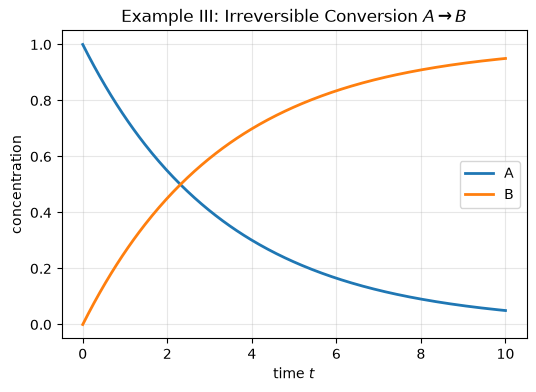

In [4]:
# --- Parameters (edit and re-run) ---
k = 0.3       # conversion rate constant (1/time)
A0 = 1.0      # initial concentration of A
B0 = 0.0      # initial concentration of B
t_span = (0, 10)
t_eval = np.linspace(*t_span, 300)

def conversion_rhs(t, y, k):
    A, B = y
    return [-k * A, k * A]

sol = solve_ivp(conversion_rhs, t_span, [A0, B0], t_eval=t_eval, args=(k,))
A_numeric, B_numeric = sol.y

total0 = A0 + B0
total_final = A_numeric[-1] + B_numeric[-1]
print(f"Conservation A+B: start = {total0:.3f}, end = {total_final:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_eval, A_numeric, label="A", lw=2)
ax.plot(t_eval, B_numeric, label="B", lw=2)
ax.set_xlabel("time $t$")
ax.set_ylabel("concentration")
ax.set_title(r"Example III: Irreversible Conversion $A \to B$")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


Total mass is conserved throughout the simulation, not just at the endpoints --- try plotting `A_numeric + B_numeric` against time yourself as a quick sanity-check exercise; it should be a flat line at $A_0+B_0$.


## Example IV: Reversible Conversion

Now let the conversion run both ways: $A \rightleftharpoons B$ with forward rate constant $k_+$ and reverse rate constant $k_-$.

$$
\frac{dA}{dt} = -k_+ A + k_- B, \qquad \frac{dB}{dt} = k_+ A - k_- B
$$

As in Example III, the total amount is conserved: $A(t)+B(t) = A_0+B_0$. Setting $dA/dt = 0$ gives the **steady-state ratio**

$$
\frac{B_{ss}}{A_{ss}} = \frac{k_+}{k_-}.
$$


Steady-state B/A: theory = 4.000, numeric = 3.999
Conservation A+B: start = 1.000, end = 1.000


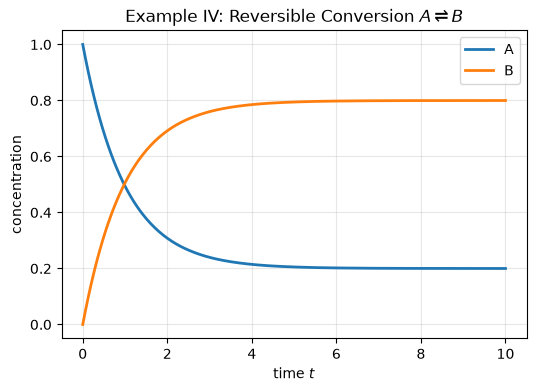

In [5]:
# --- Parameters (edit and re-run) ---
kp = 0.8      # forward rate constant k+ (1/time)
km = 0.2      # reverse rate constant k- (1/time)
A0 = 1.0      # initial concentration of A
B0 = 0.0      # initial concentration of B
t_span = (0, 10)
t_eval = np.linspace(*t_span, 300)

def reversible_rhs(t, y, kp, km):
    A, B = y
    return [-kp * A + km * B, kp * A - km * B]

sol = solve_ivp(reversible_rhs, t_span, [A0, B0], t_eval=t_eval, args=(kp, km))
A_numeric, B_numeric = sol.y

ratio_theory = kp / km
ratio_numeric = B_numeric[-1] / A_numeric[-1]
total0 = A0 + B0
total_final = A_numeric[-1] + B_numeric[-1]
print(f"Steady-state B/A: theory = {ratio_theory:.3f}, numeric = {ratio_numeric:.3f}")
print(f"Conservation A+B: start = {total0:.3f}, end = {total_final:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_eval, A_numeric, label="A", lw=2)
ax.plot(t_eval, B_numeric, label="B", lw=2)
ax.set_xlabel("time $t$")
ax.set_ylabel("concentration")
ax.set_title(r"Example IV: Reversible Conversion $A \rightleftharpoons B$")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


Only the *ratio* $k_+/k_-$, not the absolute values of $k_+$ and $k_-$, fixes the steady state. Try it yourself: set `kp = km` (equal partition, ratio 1) and then `kp` much larger than `km` (nearly all mass ends up in $B$), then re-run --- the plot and printed ratio should confirm the intuition.


## Summary

| Example | ODE(s) | Steady state / long-time behavior |
|---|---|---|
| I. Decay | $\dot A = -k_dA$ | $A\to 0$, half-life $\ln2/k_d$ |
| II. Production and Decay | $\dot A = k_p-k_dA$ | $A_{ss}=k_p/k_d$ |
| III. Irreversible Conversion | $\dot A=-kA,\ \dot B=kA$ | $A\to0,\ B\to A_0+B_0$ |
| IV. Reversible Conversion | $\dot A=-k_+A+k_-B,\ \dot B=k_+A-k_-B$ | $B_{ss}/A_{ss}=k_+/k_-$ |

**Reference:** Ingalls, B. P. (2013). *Mathematical Modeling in Systems Biology: An Introduction*. MIT Press. Chapter 2, §2.1.3. Official PDF (with solutions): <https://www.math.uwaterloo.ca/~bingalls/MMSB/MMSB_w_solutions.pdf>

See also the course's lecture-notes repo, [`lab-biotek-bio-ugm/TKBM262615`](https://github.com/lab-biotek-bio-ugm/TKBM262615), for the accompanying theory (Week 2--3: Chemical Reaction Networks).
